In [1]:
user = r"\vie43sq"
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import numpy as np
import src.fluorophore_systems as fs
import src.figures as fi

%load_ext autoreload
%autoreload 2

# Binned photon counts 
Intensity distributions based on different photon count bin sizes

### 1 fluorophore, S0 S1 T1 Cis system

In [2]:
rate_dict = dict(k_tS0_tS1=[7e6, "excitation"],
                 k_tS1_tS0=[1e9, "emission"],
                 k_tS1_tT1=[1e6, "intersystem crossing"],
                 k_tT1_tS0=[5e5, "triplet deexcitation"],
                 
                 k_tS1_Cis=[2e7, "isomerization"],
                 k_Cis_tS0=[1e5, "backisomerization"])

In [4]:
system = fs.Cy5CisModel(number=1,  distances=1, rates=rate_dict)

In [5]:
system.simulate(n_steps=10000000, seed=99, base="py")

In [8]:
system.process()

Check if ~50% are Cis

In [9]:
trans = np.sum(system.occupation_time_total[:3])
cis = np.sum(system.occupation_time_total[3:])
print(trans)
print(cis)

0.721123709202053
0.969622487921662


## 0.1 µs

In [10]:
system.emitters(unit="s", resample="0.1us", photon_collection=0.1)

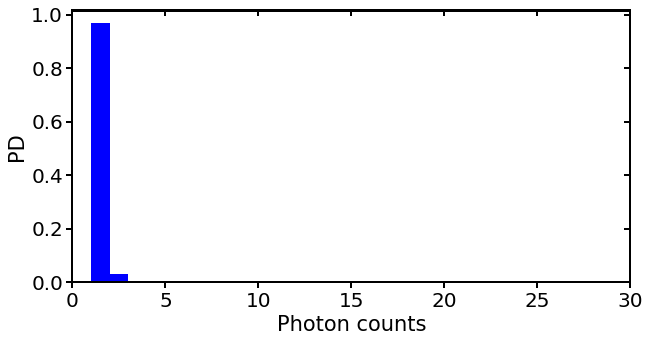

In [12]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=3,
                                                      xlim=[0, 30])

## 1 µs

In [13]:
system.emitters(unit="s", resample="1us", photon_collection=0.1)

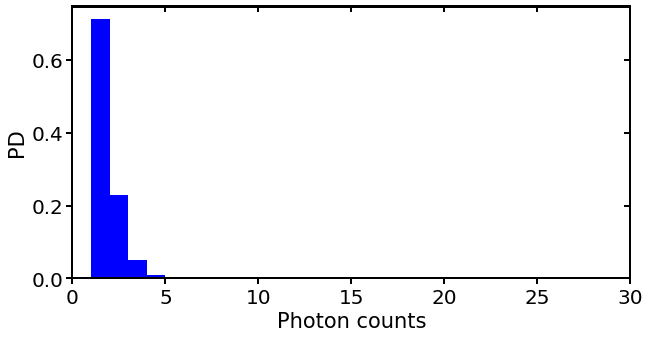

In [15]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=6,
                                                      xlim=[0, 30])

## 10 µs

In [16]:
system.emitters(unit="s", resample="10us", photon_collection=0.1)

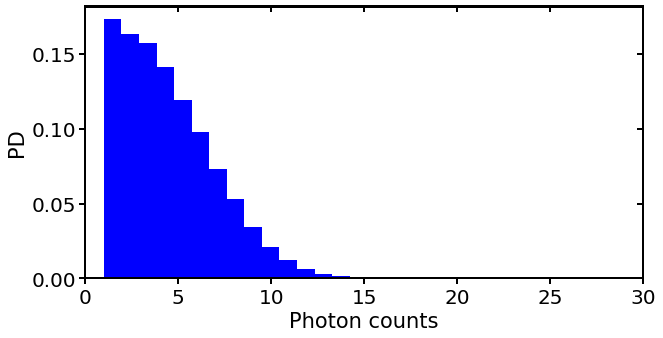

In [22]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=18,
                                                      xlim=[0, 30])

## 0.1 ms

In [23]:
system.emitters(unit="s", resample="0.1ms", photon_collection=0.1)

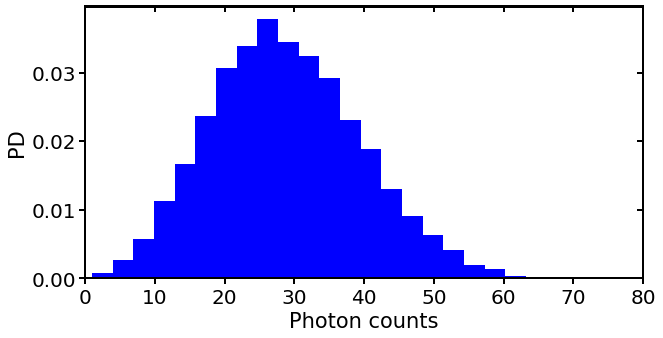

In [27]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=26,
                                                      xlim=[0, 80])

## 1 ms

In [28]:
system.emitters(unit="s", resample="1ms", photon_collection=0.1)

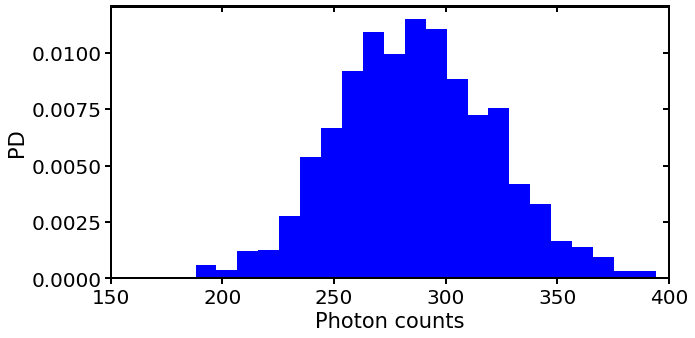

In [36]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=24,
                                                      xlim=[150, 400])

## 10 ms

In [37]:
system.emitters(unit="s", resample="10ms", photon_collection=0.1)

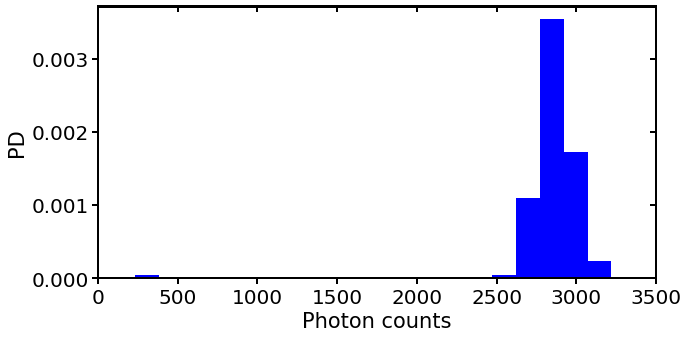

In [39]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=20,
                                                      xlim=[0, 3500])